# Randomization, peer construction, and timing

This notebook asks whether the main estimate survives three different challenges: changing the reviewed economic signs, changing the peer benchmark or observation weights, and measuring the response at later horizons.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pm_price_discovery.results import add_confidence_interval, load_result_table

ROOT = Path.cwd()
if not (ROOT / "data" / "derived").exists():
    ROOT = ROOT.parent
DATA = ROOT / "data" / "derived"
FIGURES = ROOT / "figures"

## 1. Randomize the economic signs

The link set and stock outcomes are held fixed while the reviewed +1/−1 assignments are replaced. The exact-balance design preserves the number of positive and negative signs; the within-platform design also preserves the composition separately within Kalshi and Polymarket.

In [2]:
summary = load_result_table(DATA / "h1_sign_randomization_summary.csv")
summary[[
    "null_type", "draws", "observed_beta", "pvalue_two_sided",
    "q025", "q975",
]].round(3)

Null design,Draws,Observed beta,Two-sided p,2.5%,97.5%
Rademacher 50/50,49999,2.773,0.028,-2.503,2.493
Bernoulli observed share,49999,2.773,0.026,-1.429,2.792
Exact balance permutation,49999,2.773,0.026,-1.419,2.797
Within-platform exact permutation,49999,2.773,0.024,-1.429,2.743


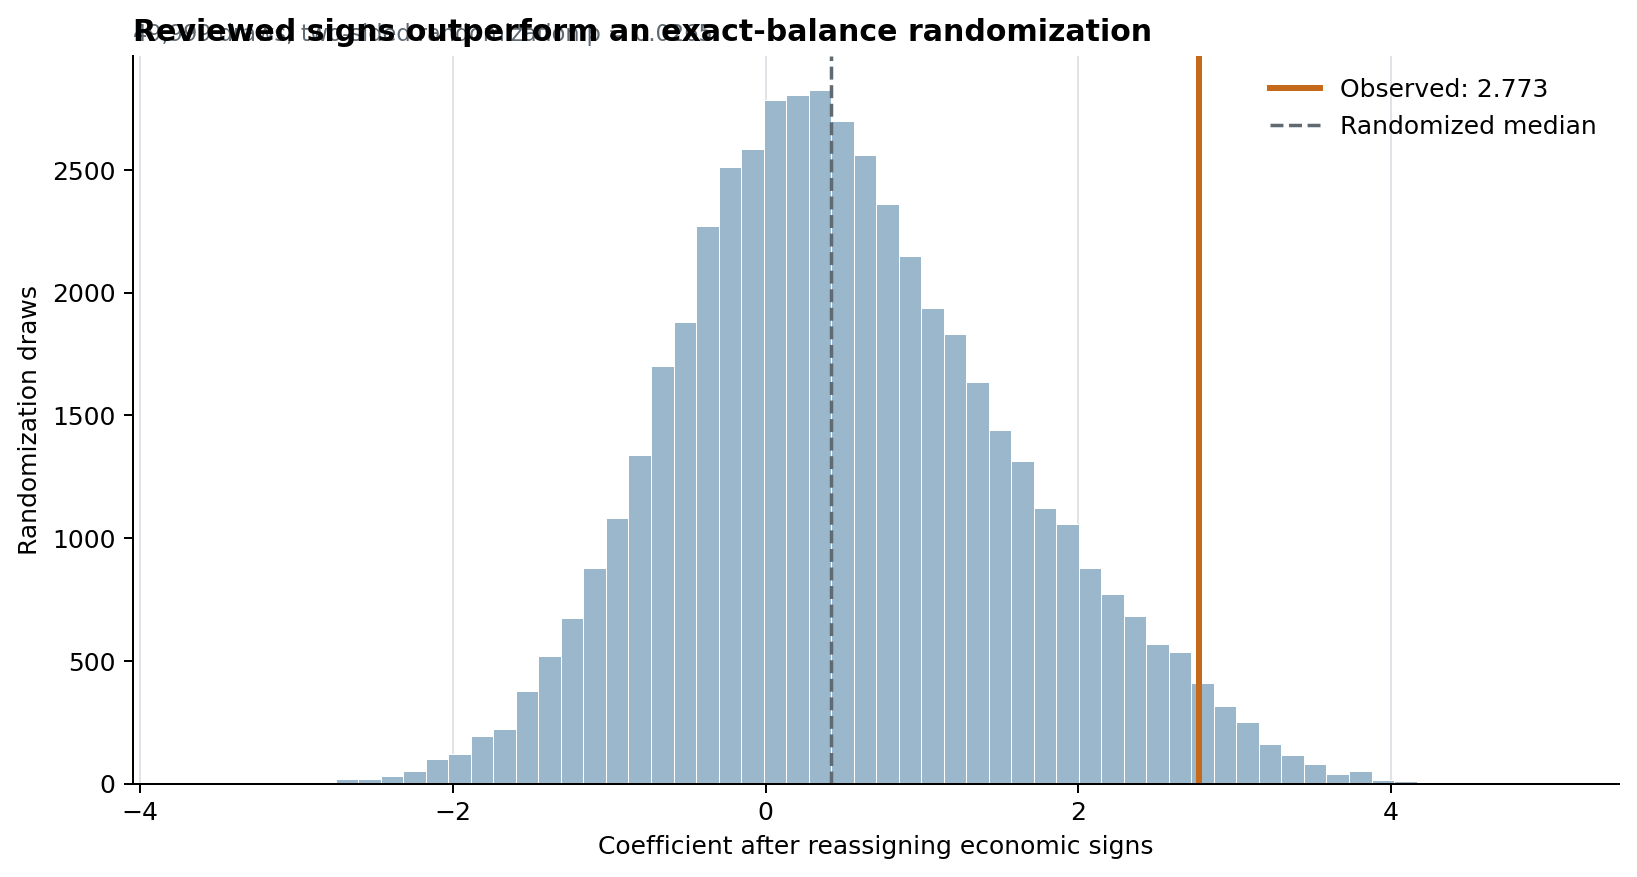

In [3]:
draws = pd.read_csv(DATA / "h1_sign_randomization_draws.csv.gz")
exact = draws.loc[draws["null_type"].eq("exact_balance_permutation"), "beta"]
observed = float(summary.loc[summary["null_type"].eq("Exact balance permutation"), "observed_beta"].iloc[0])

fig, ax = plt.subplots(figsize=(9.2, 5.0))
ax.hist(exact, bins=60, color="#9bb7cc", edgecolor="white", linewidth=0.4)
ax.axvline(observed, color="#c56a1a", linewidth=2.4, label=f"Observed: {observed:.3f}")
ax.axvline(exact.median(), color="#606a73", linestyle="--", linewidth=1.4, label="Randomized median")
ax.set_xlabel("Coefficient after reassigning economic signs")
ax.set_ylabel("Randomization draws")
ax.set_title("Reviewed signs outperform an exact-balance randomization", loc="left", weight="bold")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#d9dee3", linewidth=0.8)
fig.tight_layout()
fig.savefig(FIGURES / "h1_sign_randomization.png", dpi=180, bbox_inches="tight")
plt.show()

The observed coefficient lies beyond the central 95% interval under each randomization design. The two-sided randomization p-values range from 0.024 to 0.028.

## 2. Peer, weighting, and influence checks

These estimates alter the matched-peer outcome, equalize contributions across links/stocks/dates, or remove the highest-leverage links. The point estimate remains positive in every displayed check.

In [4]:
robust = load_result_table(
    DATA / "h1_robustness_checks.csv",
    required_columns=["family", "label", "beta", "se", "pvalue"],
)
robust[["family", "label", "beta", "se", "pvalue", "observations"]].round(3)

Check,Specification,Beta,SE,p-value,N
Baseline,Primary specification,2.773,1.263,0.028,1173
Peer construction,Add all peer-mismatch controls,2.637,1.234,0.033,1173
Peer construction,Inverse-distance peer outcome,2.812,1.234,0.023,1173
Weighting,Equal link weight,2.658,1.605,0.098,1173
Weighting,Equal stock weight,2.068,1.464,0.158,1173
Weighting,Equal date weight,2.537,1.323,0.055,1173
Influence,Remove 5 highest-leverage links,2.474,1.122,0.027,1134
Influence,Remove 10 highest-leverage links,2.073,1.050,0.048,1062
Influence,Remove 17 highest-leverage links,2.482,1.271,0.051,1000


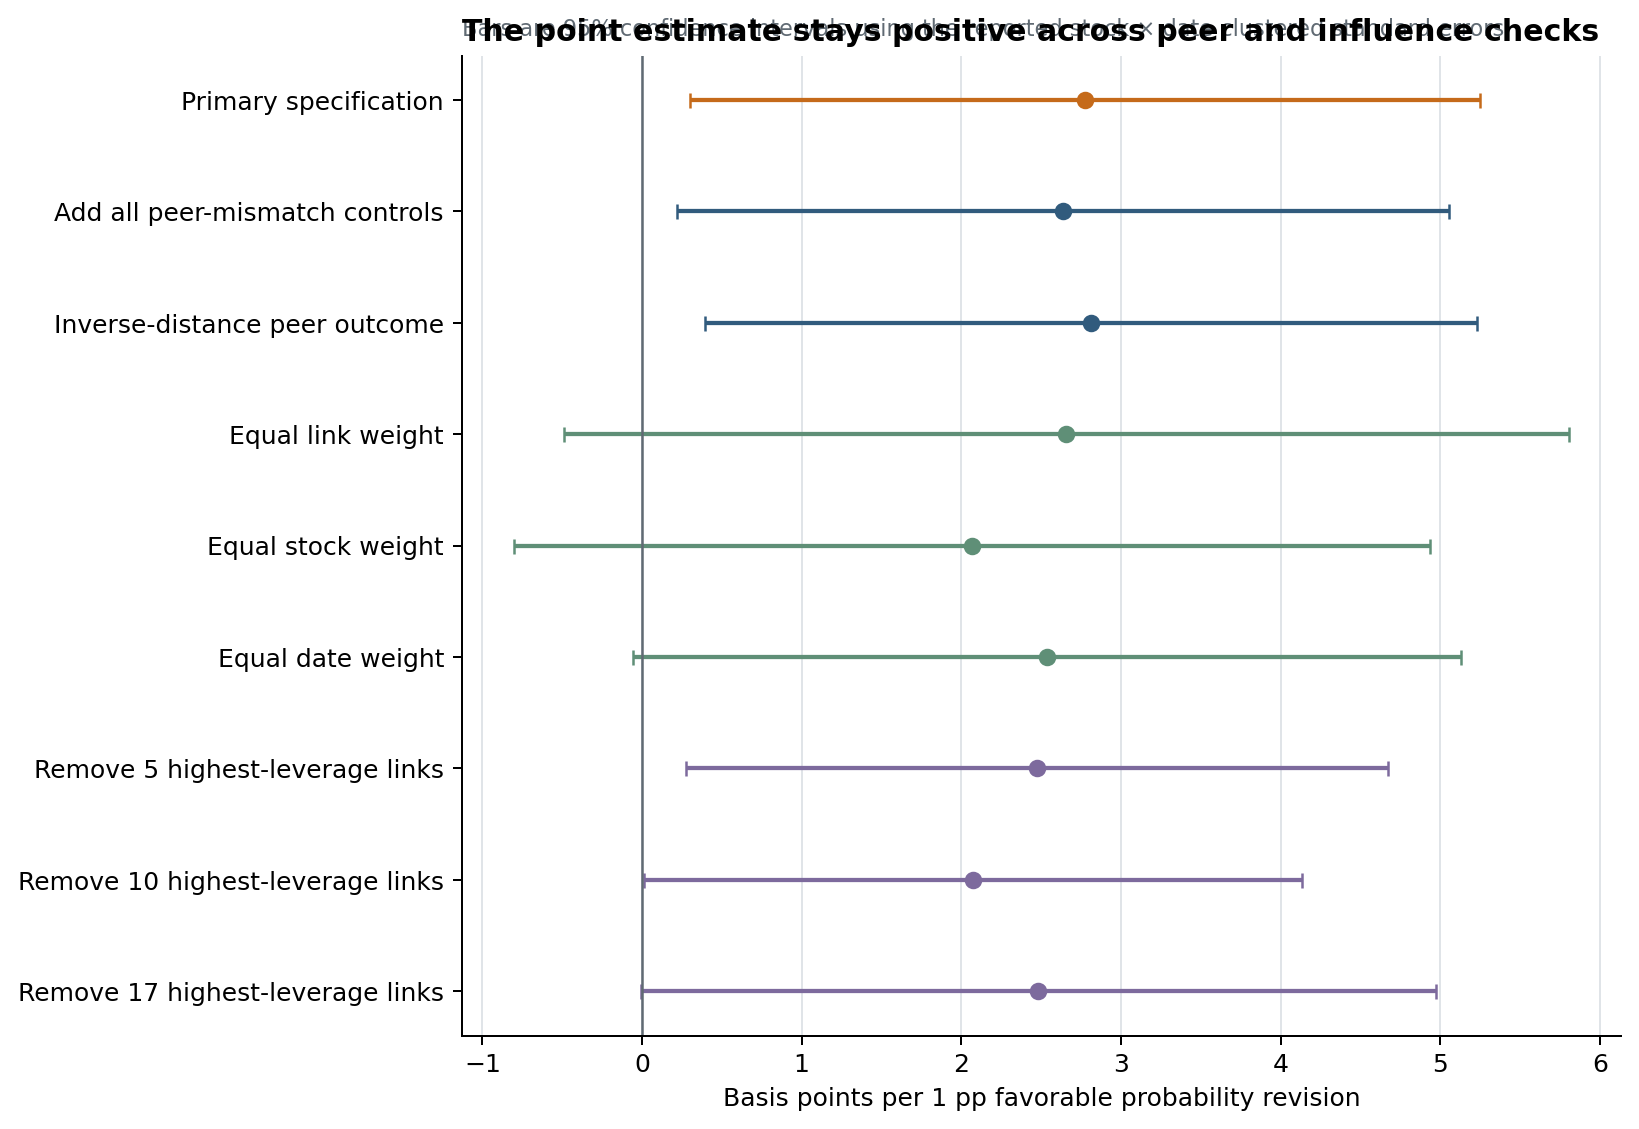

In [5]:
plot_data = add_confidence_interval(robust)
y = np.arange(len(plot_data))
palette = {
    "Baseline": "#c56a1a",
    "Peer construction": "#315b7d",
    "Weighting": "#5f8f77",
    "Influence": "#7d6a9d",
}

fig, ax = plt.subplots(figsize=(9.2, 6.4))
for position, row in zip(y, plot_data.itertuples()):
    color = palette[row.family]
    ax.errorbar(
        row.beta, position,
        xerr=[[row.beta - row.ci_low], [row.ci_high - row.beta]],
        fmt="o", color=color, ecolor=color, capsize=3,
    )
ax.axvline(0, color="#606a73", linewidth=1)
ax.set_yticks(y, plot_data["label"])
ax.invert_yaxis()
ax.set_xlabel("Basis points per 1 pp favorable probability revision")
ax.set_title("The point estimate stays positive across peer and influence checks", loc="left", weight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#d9dee3", linewidth=0.8)
fig.tight_layout()
fig.savefig(FIGURES / "h1_robustness_checks.png", dpi=180, bbox_inches="tight")
plt.show()

## 3. Same-support response across horizons

The final panel fixes a 717-observation common support and measures the linked-minus-peer response at successive horizons. Later estimates remain positive, with no evidence of a systematic post-open reversal.

In [6]:
dynamic = load_result_table(DATA / "h1_dynamic_response.csv")
dynamic[["label", "beta", "se", "pvalue", "observations"]].round(3)

Horizon,Beta,SE,p-value,N
1 minute,1.167,1.412,0.408,717
3 minutes,2.454,1.145,0.032,717
5 minutes,2.713,1.083,0.012,717
10 minutes,2.319,1.493,0.120,717
15 minutes,3.250,1.349,0.016,717
30 minutes,2.917,1.905,0.126,717
60 minutes,2.998,1.471,0.042,717
Close,3.483,1.842,0.059,717


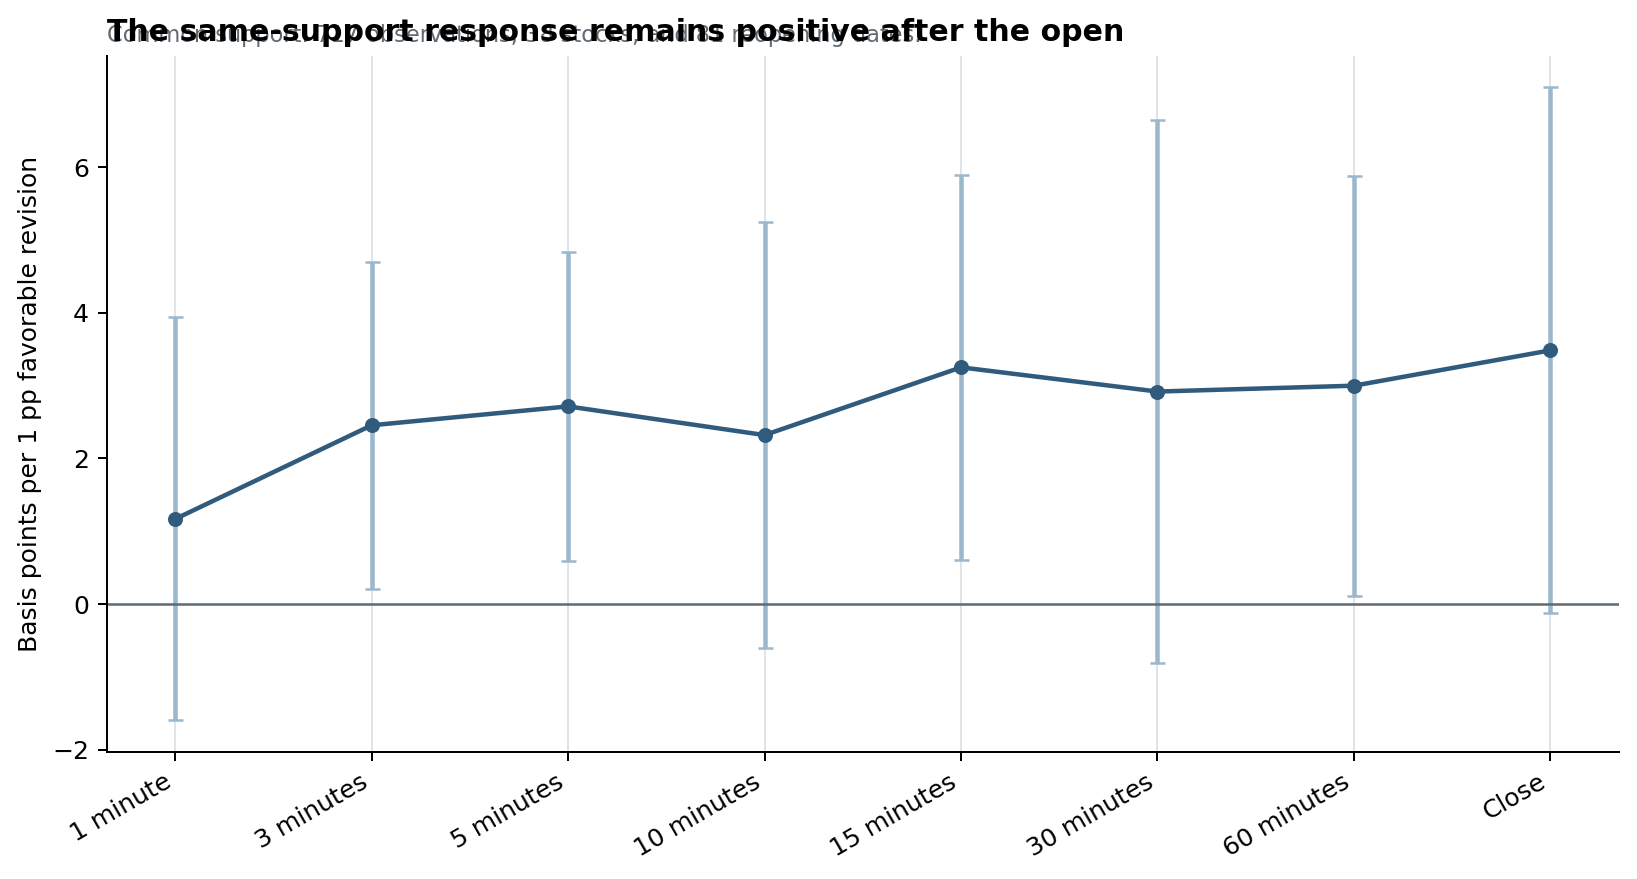

In [7]:
x = np.arange(len(dynamic))
fig, ax = plt.subplots(figsize=(9.2, 5.0))
ax.errorbar(
    x, dynamic["beta"], yerr=1.96 * dynamic["se"],
    fmt="o-", color="#315b7d", ecolor="#9bb7cc", capsize=3,
)
ax.axhline(0, color="#606a73", linewidth=1)
ax.set_xticks(x, dynamic["label"], rotation=30, ha="right")
ax.set_ylabel("Basis points per 1 pp favorable revision")
ax.set_title("The same-support response remains positive after the open", loc="left", weight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#d9dee3", linewidth=0.8)
fig.tight_layout()
fig.savefig(FIGURES / "h1_dynamic_response.png", dpi=180, bbox_inches="tight")
plt.show()

## Takeaway

The result is not tied to one convenient sign assignment, one peer definition, or a small set of influential links. Precision varies when observations are reweighted or removed, as it should, but the economic direction is stable. The response is visible at the reopening and does not subsequently reverse.